# Notebook 10 — Model Explainability and Business Risk Scoring

## Objective

This notebook explains the final XGBoost churn model, identifies the most influential variables, analyses the impact of prediction thresholds, and converts churn probabilities into operational risk segments.

The objective is to transform the predictive model into actionable business insights for customer retention.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_modelisation.parquet"
)

MODEL_FILE = (
    PROJECT_ROOT
    / "models"
    / "xgboost_churn_model.joblib"
)

TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "explainability"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_parquet(DATA_FILE)
model = joblib.load(MODEL_FILE)

TARGET = "CHURN"
ID_COLUMN = "CUSTOMER_NO"

X = df.drop(
    columns=[
        TARGET,
        ID_COLUMN,
        "JOURS_DEPUIS_REVUE"
    ]
)

y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Rows       : {len(df):,}")
print(f"Features   : {X.shape[1]}")
print(f"Churn rate : {y.mean() * 100:.2f}%")

Rows       : 195,120
Features   : 17
Churn rate : 5.41%


In [4]:
preprocessor = model.named_steps["preprocessing"]
classifier = model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

print(f"Transformed features: {len(feature_names)}")
print(feature_names[:10])

Transformed features: 41
['AGE', 'ANCIENNETE_CLIENT_ANNEES', 'SALAIRE', 'JOURS_AVANT_PROCHAINE_REVUE', 'NB_COMPTES', 'TRANCHE_AGE_15-25', 'TRANCHE_AGE_26-35', 'TRANCHE_AGE_36-50', 'TRANCHE_AGE_51-65', 'TRANCHE_AGE_65+']


In [ ]:
importance_df = pd.DataFrame({
    "FEATURE": feature_names,
    "IMPORTANCE": classifier.feature_importances_
}).sort_values(
    "IMPORTANCE",
    ascending=False
)
top20 = importance_df.head(20)

top20.to_excel(
    TABLES_DIR /
    "top20_features.xlsx",
    index=False
)

display(importance_df.head(15))

importance_df.to_excel(
    TABLES_DIR / "xgboost_feature_importance.xlsx",
    index=False
)
top10 = importance_df.head(10)

display(top10)

top10.to_excel(
    TABLES_DIR /
    "top10_feature_importance.xlsx",
    index=False
)

,FEATURE,IMPORTANCE
27,SEGMENT_Retail,0.153063
13,EST_TUNISIEN_True,0.059876
12,EST_TUNISIEN_False,0.052948
4,NB_COMPTES,0.036788
34,SCORE_KYC_MR,0.034508
22,TYPE_CLIENT_PPH,0.033508
18,SITUATION_FAMILIALE_M,0.029331
14,EST_RESIDENT_False,0.027418
39,A_HISTORIQUE_REVUE_False,0.027349
38,REVUE_EN_RETARD_True,0.026529


,FEATURE,IMPORTANCE
27,SEGMENT_Retail,0.153063
13,EST_TUNISIEN_True,0.059876
12,EST_TUNISIEN_False,0.052948
4,NB_COMPTES,0.036788
34,SCORE_KYC_MR,0.034508
22,TYPE_CLIENT_PPH,0.033508
18,SITUATION_FAMILIALE_M,0.029331
14,EST_RESIDENT_False,0.027418
39,A_HISTORIQUE_REVUE_False,0.027349
38,REVUE_EN_RETARD_True,0.026529


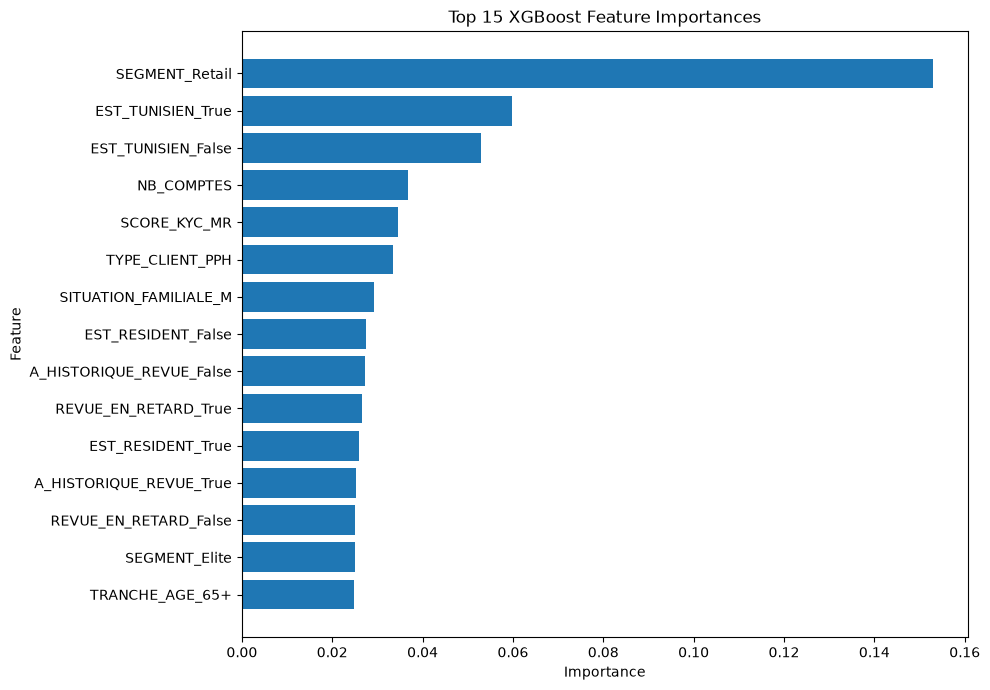

In [6]:
top_importance = importance_df.head(15).sort_values(
    "IMPORTANCE"
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance["FEATURE"],
    top_importance["IMPORTANCE"]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
X_test_sample = X_test.sample(
    n=min(3000, len(X_test)),
    random_state=42
)

X_test_transformed = preprocessor.transform(
    X_test_sample
)

print(X_test_transformed.shape)

(3000, 41)


In [8]:
explainer = shap.TreeExplainer(
    classifier
)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


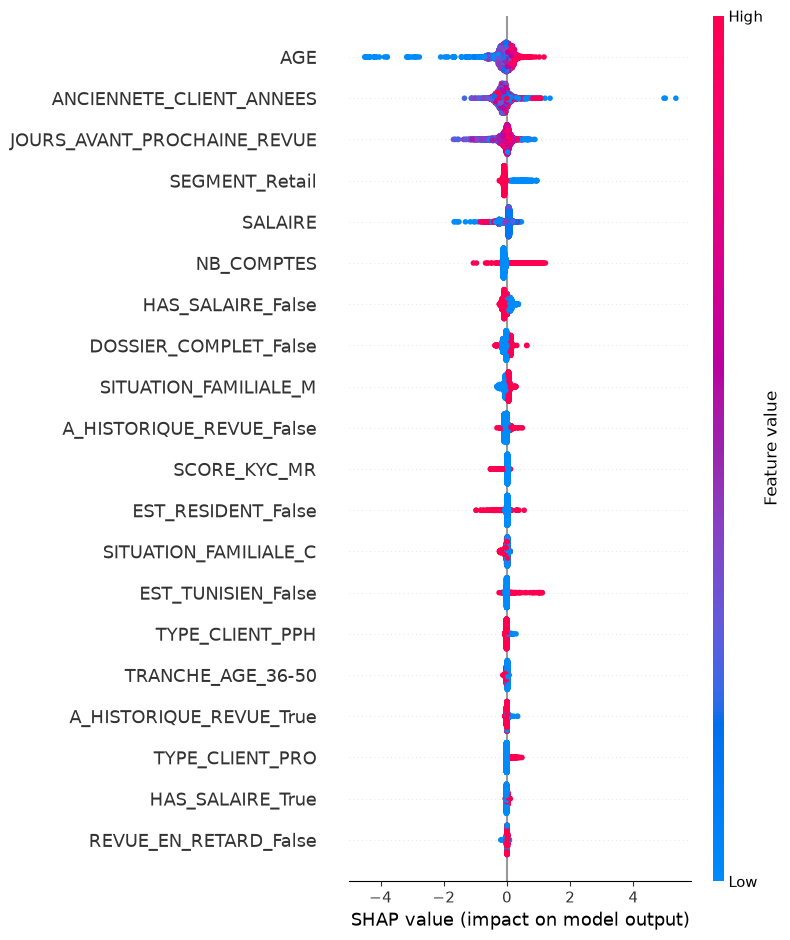

In [9]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

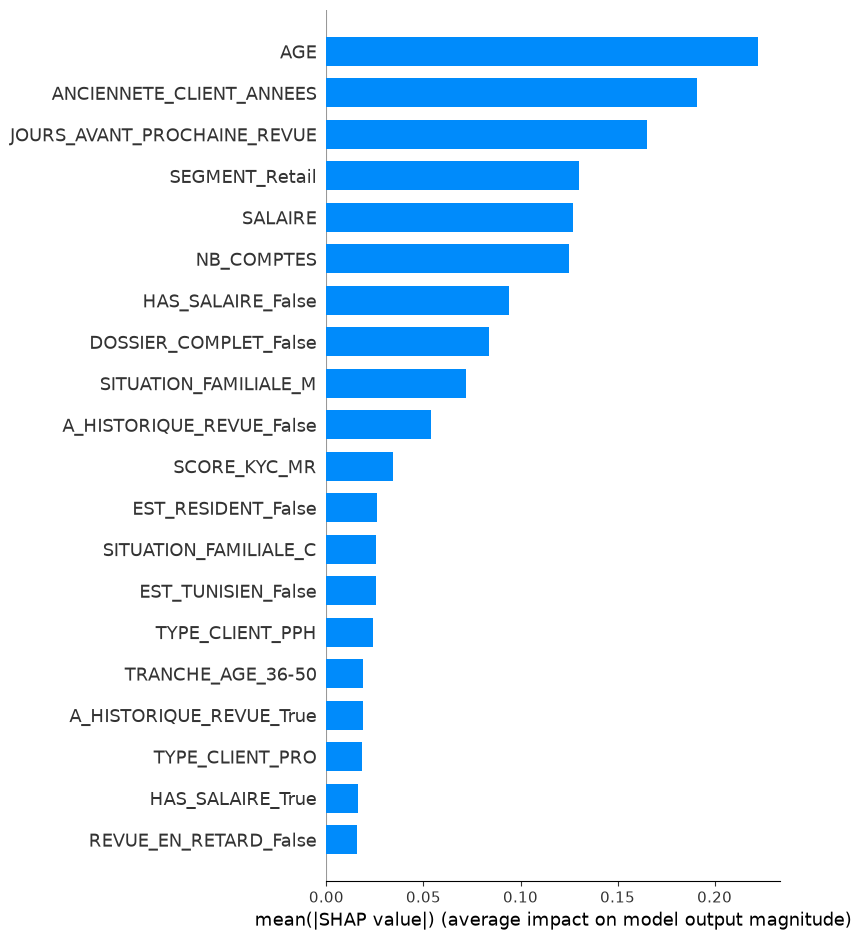

In [10]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.savefig(
    FIGURES_DIR /
    "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
y_prob = model.predict_proba(
    X_test
)[:, 1]

thresholds = [
    0.30,
    0.40,
    0.50,
    0.60
]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "THRESHOLD": threshold,
        "PRECISION": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "RECALL": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "CUSTOMERS_FLAGGED": int(
            y_pred_threshold.sum()
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

threshold_df.to_excel(
    TABLES_DIR / "threshold_analysis.xlsx",
    index=False
)

,THRESHOLD,PRECISION,RECALL,F1,CUSTOMERS_FLAGGED
0,0.3,0.064442,0.940758,0.120621,30803
1,0.4,0.079956,0.758294,0.144659,20011
2,0.5,0.116041,0.521801,0.189860,9488
3,0.6,0.159907,0.356872,0.220853,4709


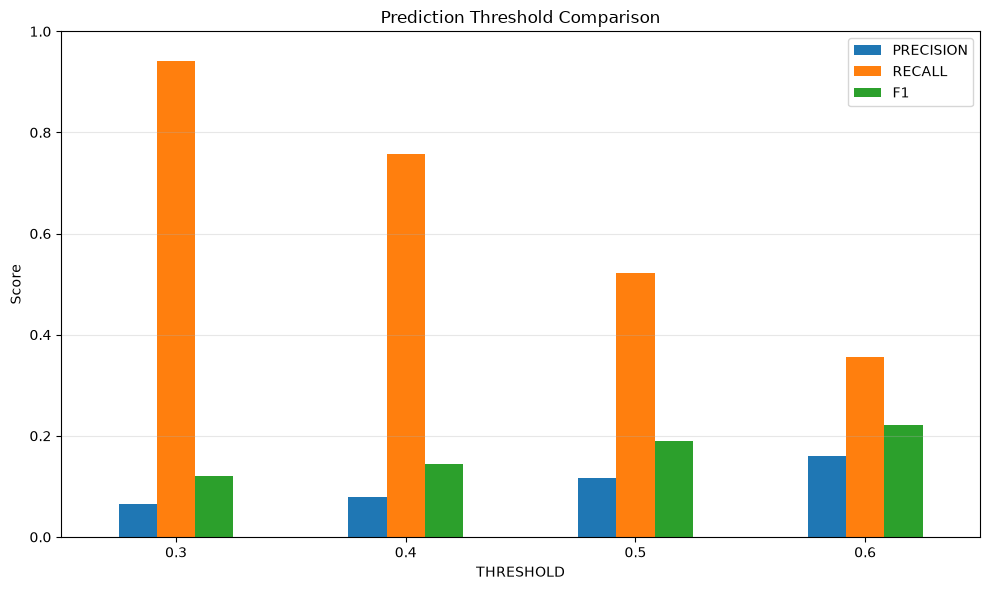

In [12]:
threshold_df.set_index(
    "THRESHOLD"
)[
    [
        "PRECISION",
        "RECALL",
        "F1"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Prediction Threshold Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "threshold_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Lower thresholds identify more churners but generate more false positive alerts.

Higher thresholds reduce operational workload but increase the probability of missing customers who will actually churn.

The operational threshold should therefore be selected according to the bank's retention capacity.

In [13]:
full_probabilities = model.predict_proba(
    X
)[:, 1]

risk_scoring = pd.DataFrame({
    "CUSTOMER_NO": df["CUSTOMER_NO"],
    "ACTUAL_CHURN": y,
    "CHURN_PROBABILITY": full_probabilities
})

risk_scoring["CHURN_SCORE"] = (
    risk_scoring["CHURN_PROBABILITY"]
    * 100
).round(2)

In [14]:
risk_scoring["RISK_LEVEL"] = pd.cut(
    risk_scoring["CHURN_PROBABILITY"],
    bins=[
        -np.inf,
        0.30,
        0.50,
        0.70,
        np.inf
    ],
    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "CRITICAL"
    ]
)

display(
    risk_scoring["RISK_LEVEL"]
    .value_counts()
    .sort_index()
)

RISK_LEVEL
LOW          41362
MEDIUM      105414
HIGH         38426
CRITICAL      9918
Name: count, dtype: int64

In [15]:
RISK_OUTPUT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_churn_risk_scores.parquet"
)

risk_scoring.to_parquet(
    RISK_OUTPUT,
    index=False
)

risk_scoring.to_excel(
    TABLES_DIR / "customer_churn_risk_scores.xlsx",
    index=False
)

print(f"Risk scores exported: {RISK_OUTPUT}")

Risk scores exported: c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\data\processed\customer_churn_risk_scores.parquet


In [16]:
high_risk_customers = (
    risk_scoring[
        risk_scoring["RISK_LEVEL"].isin(
            [
                "HIGH",
                "CRITICAL"
            ]
        )
    ]
    .sort_values(
        "CHURN_PROBABILITY",
        ascending=False
    )
)

display(
    high_risk_customers.head(20)
)

high_risk_customers.to_excel(
    TABLES_DIR / "high_risk_customers.xlsx",
    index=False
)

,CUSTOMER_NO,ACTUAL_CHURN,CHURN_PROBABILITY,CHURN_SCORE,RISK_LEVEL
17224,113102284,1,0.998703,99.870003,CRITICAL
58407,113129416,1,0.997493,99.750000,CRITICAL
52669,113151189,1,0.997416,99.739998,CRITICAL
160892,113189564,1,0.997252,99.730003,CRITICAL
154524,113105370,1,0.996838,99.680000,CRITICAL
136431,113103669,1,0.996781,99.680000,CRITICAL
63861,113122297,1,0.996772,99.680000,CRITICAL
115523,113115505,1,0.996749,99.669998,CRITICAL
134924,113145292,1,0.996698,99.669998,CRITICAL
192442,113102099,1,0.996680,99.669998,CRITICAL


In [17]:
risk_summary = (

risk_scoring

.groupby("RISK_LEVEL")

.agg(

CUSTOMERS=("CUSTOMER_NO","count"),

AVG_PROBABILITY=(

"CHURN_PROBABILITY",

"mean"

)

)

)

display(risk_summary)

,CUSTOMERS,AVG_PROBABILITY
RISK_LEVEL,,
LOW,41362,0.183026
MEDIUM,105414,0.399486
HIGH,38426,0.580265
CRITICAL,9918,0.795146


In [20]:
risk_summary = (
    risk_scoring
    .groupby("RISK_LEVEL")
    .agg(
        CUSTOMERS=("CUSTOMER_NO", "count"),
        AVG_PROBABILITY=("CHURN_PROBABILITY", "mean")
    )
)

display(risk_summary)

risk_summary.to_excel(
    TABLES_DIR /
    "risk_summary.xlsx"
)

,CUSTOMERS,AVG_PROBABILITY
RISK_LEVEL,,
LOW,41362,0.183026
MEDIUM,105414,0.399486
HIGH,38426,0.580265
CRITICAL,9918,0.795146


# Business Interpretation — Model Explainability

The explainability analysis identifies the customer characteristics that contribute most strongly to churn risk according to the final XGBoost model.

Global feature importance shows which variables are most frequently used by the model, while SHAP values explain both the magnitude and direction of each variable's contribution.

The threshold analysis demonstrates that the operational decision threshold should be selected according to the bank's retention capacity. Lower thresholds increase recall and identify more potential churners, but they also generate more false positive alerts. Higher thresholds improve precision but may miss a larger proportion of customers who eventually churn.

The final churn probability is therefore converted into risk segments:

- LOW: limited immediate churn risk.
- MEDIUM: customer should be monitored.
- HIGH: proactive retention action recommended.
- CRITICAL: priority intervention required.

These risk segments can be integrated into the final dashboard to support targeted customer retention campaigns.

In [18]:
print("=" * 70)
print("NOTEBOOK 10 COMPLETED")
print("=" * 70)

print("✓ Final XGBoost model loaded")
print("✓ Feature importance calculated")
print("✓ SHAP analysis completed")
print("✓ Threshold analysis completed")
print("✓ Customer churn scores generated")
print("✓ Risk segments created")
print("✓ High-risk customer list exported")
print("✓ Business recommendations documented")

print(
    f"\nCustomers scored : "
    f"{len(risk_scoring):,}"
)

print(
    f"High/Critical risk customers : "
    f"{len(high_risk_customers):,}"
)

NOTEBOOK 10 COMPLETED
✓ Final XGBoost model loaded
✓ Feature importance calculated
✓ SHAP analysis completed
✓ Threshold analysis completed
✓ Customer churn scores generated
✓ Risk segments created
✓ High-risk customer list exported
✓ Business recommendations documented

Customers scored : 195,120
High/Critical risk customers : 48,344


# Final Project Conclusion

The proposed customer churn prediction framework combines robust data engineering, temporal target construction, exploratory data analysis, machine learning and explainability techniques.

Among all evaluated algorithms, XGBoost achieved the strongest overall predictive performance while maintaining the highest churn detection capability.

The explainability analysis demonstrates that the model decisions are transparent and can be interpreted through feature importance and SHAP values.

The resulting churn probability can therefore be integrated into banking retention strategies to prioritize proactive interventions for customers at the highest risk of leaving.